# Part A : Optimization and Norm Minimization: A Geometric Exploration

## **Introduction to Optimization and Norm Minimization**

Optimization is a fundamental concept in mathematics, computer science, and engineering. It deals with finding the 'best' solution from a set of available alternatives. In many real-world scenarios, this involves minimizing or maximizing an objective function subject to certain constraints.

Norm minimization is a specific type of optimization problem where the objective is to find a vector that has the smallest possible 'size' (norm) while satisfying a given set of constraints. Different norms (like **L1, L2, and L-infinity**) define 'size' in distinct ways, leading to different geometric interpretations and applications. This notebook explores these concepts geometrically using a simple linear constraint.

We will visualize how minimizing different norms leads to different optimal solutions on a given constraint line.

## **1. Importing Necessary Libraries**

Before we begin, we need to import the libraries that will help us perform numerical operations, plotting, and convex optimization.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

## **2. Understanding the Constraint Line**

Our optimization problem is subject to a linear constraint. In this case, it's a simple equation of a line: $$x_1 + 2x_2 = 4$$

Mathematically, this constraint defines a feasible region, which is the set of all points $(x_1, x_2)$ that satisfy this equation. We will visualize this line on our plots.

To plot this line, we express $x_2$ in terms of $x_1$.

In [33]:
import numpy as np
# ----------------------------------------------------------
# Constraint:
# x1 + 2x2 = 4
# ----------------------------------------------------------

x1 = np.linspace(-5,5,400)
x2 = (4 - x1)/2

## **3. Creating Meshgrid and Norm Functions**

To visualize the norms as contours, we need a grid of points over which to calculate their values. A `meshgrid` generates 2D coordinate arrays from 1D coordinate vectors.

We then define functions for the $\mathcal{L}_1$, $\mathcal{L}_2$ (Euclidean), and $\mathcal{L}_\infty$ norms. These functions calculate the 'size' or 'magnitude' of a vector $(x_1, x_2)$ according to their respective definitions.

*   **$\mathcal{L}_1$ Norm (Manhattan Distance):** $|x_1| + |x_2|$
*   **$\mathcal{L}_2$ Norm (Euclidean Distance):** $\sqrt{x_1^2 + x_2^2}$
*   **$\mathcal{L}_\infty$ Norm (Chebyshev Distance):** $\mathrm{max}(|x_1|, |x_2|)$

In [34]:
import numpy as np
# ----------------------------------------------------------
# Meshgrid
# ----------------------------------------------------------

X1, X2 = np.meshgrid(np.linspace(-5,5,400),
                     np.linspace(-5,5,400))

# ----------------------------------------------------------
# Norms
# ----------------------------------------------------------

L1 = np.abs(X1) + np.abs(X2)

L2 = np.sqrt(X1**2 + X2**2)

Linf = np.maximum(np.abs(X1), np.abs(X2))

## **4. Convex Optimization using CVXPY**

CVXPY is an open-source Python-embedded modeling language for convex optimization problems. It allows us to define optimization variables, objectives, and constraints in a natural, mathematical syntax.

Our goal is to minimize the $\mathcal{L}_1$, $\mathcal{L}_2$, and $\mathcal{L}_\infty$ norms of a vector $\mathbf{x} = [x_1, x_2]^T$ subject to the constraint $x_1 + 2x_2 = 4$.

### **Optimization Variables and Constraints Setup**

We define our optimization variable $\mathbf{x} \in \mathbb{R}^{2 \times 1}$ as a column vector. The constraint $x_1 + 2x_2 = 4$ is represented in matrix form as

$$\mathbf{A}\mathbf{x} = b, \text{ where }\quad \mathbf{A} = [1, 2] \text{ and }  b = 4 $$

Let's break down the key functions and concepts used in this optimization code:

*   **`cp.Variable((2,1))`**: This function from the `cvxpy` library is used to declare an optimization variable. In this case, $\mathbf{x} \in \mathbb{R}^{2 \times 1}$ is defined as a column vector, meaning it has two unknown numerical values that the optimizer will determine.


*   **`constraints = [A @ x == b]`**: This line defines the conditions that the optimal solution for $\mathbf{x} \in \mathbb{R}^{2 \times 1}$ must satisfy. It forms a list (even if there's only one condition) containing the equality constraint $\mathbf{A}\mathbf{x} = \mathbf{b}$. This mathematically translates to $x_1 + 2x_2 = 4$.

In [35]:
import numpy as np
import cvxpy as cp

# ----------------------------------------------------------
# Optimization Variables
# ----------------------------------------------------------

x = cp.Variable((2,1))

A = np.array([[1,2]])
b = np.array([[4]])

constraints = [A @ x == b]

### **$\mathcal{L}_1$ Norm Minimization**

Here, we minimize the $\mathcal{L}_1$ norm of $\mathbf{x}$. The $\mathcal{L}_1$ norm encourages sparsity, meaning it tends to find solutions where more components of $\mathbf{x}$ are zero. Geometrically, its contours are diamonds centered at the origin. The optimal point is found where the smallest diamond touches the constraint line.

Let's break down the key functions and concepts used in this optimization code:

*   **`cp.Minimize(cp.norm(x,1))`**: This `cvxpy` function sets the objective of the optimization problem. We are telling the solver to find the smallest possible value of the expression `cp.norm(x,1)`. The `cp.norm(x,1)` specifically calculates the $\mathcal{L}_1$ norm of the vector $\mathbf{x}$, which is the sum of the absolute values of its components (i.e., $|x_1| + |x_2|$).

*   **`cp.Problem(objective, constraints)`**: This function assembles the complete optimization problem by combining the defined objective (what we want to minimize or maximize) and the list of constraints (the conditions that must be met).

*   **`problem.solve()`**: This method is called on the `cvxpy` problem object to initiate the optimization process. `cvxpy` will then use an appropriate solver to find the numerical values for $\mathbf{x}$ that best satisfy the problem's objective and constraints.

*   **`x.value`**: After `problem.solve()` has been executed, this attribute of the `cvxpy` variable $\mathbf{x}$ holds the numerical optimal solution found by the solver.


In [36]:
import numpy as np
import cvxpy as cp
# ----------------------------------------------------------
# L1 Norm Minimization
# ----------------------------------------------------------

objective1 = cp.Minimize(cp.norm(x,1))

problem1 = cp.Problem(objective1, constraints)

problem1.solve()

xL1 = x.value


print("L1 Optimal Solution")
print(xL1)

L1 Optimal Solution
[[5.83257106e-09]
 [2.00000000e+00]]


### **$\mathcal{L}_2$ Norm Minimization**

Minimizing the $\mathcal{L}_2$ norm (Euclidean distance) finds the point on the constraint line that is closest to the origin in the standard Euclidean sense. Its contours are circles centered at the origin. The optimal solution is the point where the smallest circle is tangent to the constraint line.

In [37]:
import numpy as np
import cvxpy as cp

# ----------------------------------------------------------
# L2 Norm Minimization
# ----------------------------------------------------------

objective2 = cp.Minimize(cp.norm(x,2))

problem2 = cp.Problem(objective2, constraints)

problem2.solve()

xL2 = x.value

print("\nL2 Optimal Solution")
print(xL2)


L2 Optimal Solution
[[0.8]
 [1.6]]


### **$\mathcal{L}_\infty$ Norm Minimization**

Minimizing the $\mathcal{L}_\infty$ norm finds the point where the maximum absolute coordinate is smallest. Its contours are squares aligned with the axes, centered at the origin. The optimal solution is where the smallest such square touches the constraint line.

In [38]:
import numpy as np
import cvxpy as cp

# ----------------------------------------------------------
# Linf Norm Minimization
# ----------------------------------------------------------

objective3 = cp.Minimize(cp.norm(x,"inf"))

problem3 = cp.Problem(objective3, constraints)

problem3.solve()

xLinf = x.value

print("\nLinf Optimal Solution")
print(xLinf)


Linf Optimal Solution
[[1.33333329]
 [1.33333335]]


## **5. Plotting Contours and Optimal Solutions**

To visualize the geometric interpretation, we will plot the contour lines for each norm and mark the optimal solution found by **CVXPY** on the constraint line. This helps us understand how the 'shape' of the norm influences the optimal point.

### **$\mathcal{L}_1$ Norm Plotting**

The first plot shows the $\mathcal{L}_1$ norm contours (diamond shapes). The red contour highlights the smallest $\mathcal{L}_1$ norm that intersects the black constraint line. The red asterisk marks the optimal point `xL1`, which has coordinates `(0, 2)` (approximately, due to numerical precision). Notice how the diamond-shaped contour 'touches' the constraint line at a corner.

The `plt.contour` function from `matplotlib` draws contour lines (isolevels) for 2D data, connecting points of equal value. It's like a topographic map for our norm functions.

Key parameters used:

*   **$x_1$, $x_2$**: 2D arrays (meshgrid) defining the x and y coordinates.
*   **$\mathcal{L}_1$ (or $\mathcal{L}_2$, $\mathcal{L}_\infty$)**: 2D array of norm values at each $(x_1, x_2)$ point.
*   **`levels`**: Determines which contour values to draw. Can be an integer for automatic spacing or a list of specific values (e.g., `[optimalLevelL1]`).
*   **`cmap='viridis'`**: Sets the color scheme for the contours.
*   **`colors`**: Specifies a color for specific contours, often used to highlight optimal levels.
*   **`linewidths`**: Sets the thickness of the contour lines, useful for emphasizing certain levels.

L1 Optimal Solution
[[5.83257106e-09]
 [2.00000000e+00]]


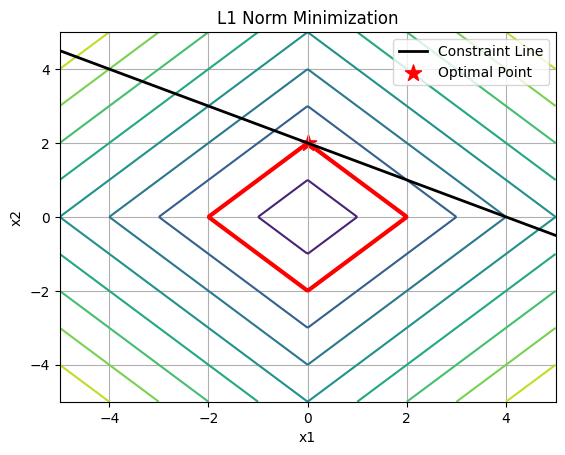

In [39]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
# ----------------------------------------------------------
# Meshgrid
# ----------------------------------------------------------

X1, X2 = np.meshgrid(np.linspace(-5,5,400),
                     np.linspace(-5,5,400))

# ----------------------------------------------------------
# Norms
# ----------------------------------------------------------

L1 = np.abs(X1) + np.abs(X2)
# ----------------------------------------------------------
# Optimization Variables
# ----------------------------------------------------------

x = cp.Variable((2,1))

A = np.array([[1,2]])
b = np.array([[4]])

constraints = [A @ x == b]

# ----------------------------------------------------------
# L1 Norm Minimization
# ----------------------------------------------------------

objective1 = cp.Minimize(cp.norm(x,1))

problem1 = cp.Problem(objective1, constraints)

problem1.solve()

xL1 = x.value


print("L1 Optimal Solution")
print(xL1)

# ----------------------------------------------------------
# Plotting
# ----------------------------------------------------------
# fig, axs = plt.subplots(1,4, figsize=(18,5))


# ==========================================================
# L1 Norm
# ==========================================================

# Normal contours
plt.contour(X1, X2, L1,
               levels= 10,
               cmap='viridis')

# Special contour through optimal point
optimalLevelL1 = np.abs(xL1[0,0]) + np.abs(xL1[1,0])

plt.contour(X1, X2, L1,
               levels=[optimalLevelL1],
               colors='red',
               linewidths=3)

# Constraint line
plt.plot(x1, x2,
            '-k',
            linewidth=2,
            label='Constraint Line')

# Optimal point
plt.scatter(xL1[0,0],
               xL1[1,0],
               color='red',
               s=150,
               marker='*',
               label='Optimal Point')

plt.title('L1 Norm Minimization')

plt.xlabel('x1')
plt.ylabel('x2')

plt.xlim([-5,5])
plt.ylim([-5,5])

plt.grid()

plt.legend()

### **$\mathcal{L}_2$ Norm Plotting**

The second plot displays the $\mathcal{L}_2$ norm contours (circles). The green contour shows the smallest $\mathcal{L}_2$ norm circle that is tangent to the black constraint line. The green triangle indicates the optimal point `xL2`, which is `(0.8, 1.6)`. This point is the perpendicular projection of the origin onto the constraint line.


L2 Optimal Solution
[[0.8]
 [1.6]]


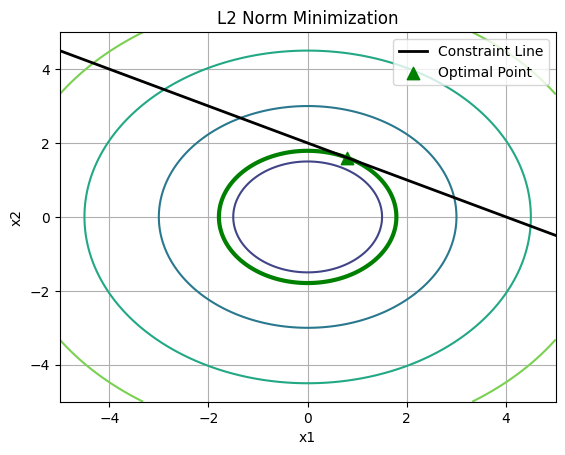

In [40]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
# ----------------------------------------------------------
# Meshgrid
# ----------------------------------------------------------

X1, X2 = np.meshgrid(np.linspace(-5,5,400),
                     np.linspace(-5,5,400))

# ----------------------------------------------------------
# Norms
# ----------------------------------------------------------

L2 = np.sqrt(X1**2 + X2**2)
# ----------------------------------------------------------
# Optimization Variables
# ----------------------------------------------------------

x = cp.Variable((2,1))

A = np.array([[1,2]])
b = np.array([[4]])

constraints = [A @ x == b]
# ----------------------------------------------------------
# L2 Norm Minimization
# ----------------------------------------------------------

objective2 = cp.Minimize(cp.norm(x,2))

problem2 = cp.Problem(objective2, constraints)

problem2.solve()

xL2 = x.value

print("\nL2 Optimal Solution")
print(xL2)
# ==========================================================
# L2 Norm
# ==========================================================

plt.contour(X1, X2, L2,
               levels=6,
               cmap='viridis')

# Special contour through optimal point
optimalLevelL2 = np.sqrt(xL2[0,0]**2 + xL2[1,0]**2)

plt.contour(X1, X2, L2,
               levels=[optimalLevelL2],
               colors='green',
               linewidths=3)

# Constraint line
plt.plot(x1, x2,
            '-k',
            linewidth=2,
            label='Constraint Line')

# Optimal point
plt.scatter(xL2[0,0],
               xL2[1,0],
               color='green',
               s=80,
               marker='^',
               label='Optimal Point')

plt.title('L2 Norm Minimization')

plt.xlabel('x1')
plt.ylabel('x2')

plt.xlim([-5,5])
plt.ylim([-5,5])

plt.grid()

plt.legend()

### **$\mathcal{L}_\infty$ Norm Plotting**

The third plot illustrates the$\mathcal{L}_\infty$ norm contours (squares). The blue contour represents the smallest $\mathcal{L}_\infty$ norm square that intersects the constraint line. The blue dot marks the optimal point `xLinf`, which is approximately `(1.33, 1.33)`. Here, the square-shaped contour 'touches' the constraint line.


Linf Optimal Solution
[[1.33333329]
 [1.33333335]]


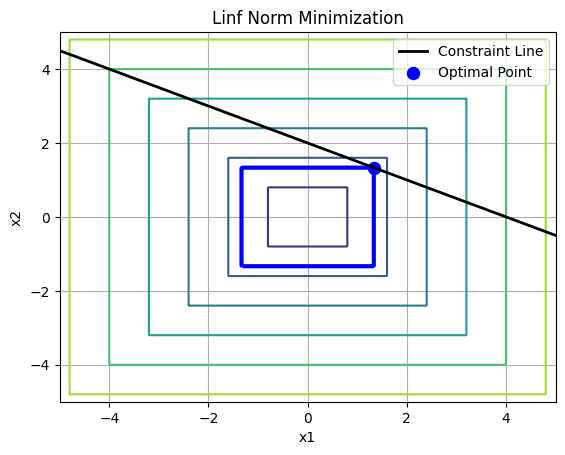

In [41]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
# ----------------------------------------------------------
# Meshgrid
# ----------------------------------------------------------

X1, X2 = np.meshgrid(np.linspace(-5,5,400),
                     np.linspace(-5,5,400))

# ----------------------------------------------------------
# Norms
# ----------------------------------------------------------

Linf = np.maximum(np.abs(X1), np.abs(X2))
# ----------------------------------------------------------
# Optimization Variables
# ----------------------------------------------------------

x = cp.Variable((2,1))

A = np.array([[1,2]])
b = np.array([[4]])

constraints = [A @ x == b]

# ----------------------------------------------------------
# Linf Norm Minimization
# ----------------------------------------------------------

objective3 = cp.Minimize(cp.norm(x,"inf"))

problem3 = cp.Problem(objective3, constraints)

problem3.solve()

xLinf = x.value

print("\nLinf Optimal Solution")
print(xLinf)
# ==========================================================
# Linf Norm
# ==========================================================

plt.contour(X1, X2, Linf,
               levels=6,
               cmap='viridis')

# Special contour through optimal point
optimalLevelLinf = np.maximum(np.abs(xLinf[0,0]),
                              np.abs(xLinf[1,0]))

plt.contour(X1, X2, Linf,
               levels=[optimalLevelLinf],
               colors='blue',
               linewidths=3)

# Constraint line
plt.plot(x1, x2,
            '-k',
            linewidth=2,
            label='Constraint Line')

# Optimal point
plt.scatter(xLinf[0,0],
               xLinf[1,0],
               color='blue',
               s=300,
               marker='.',
               label='Optimal Point')

plt.title('Linf Norm Minimization')

plt.xlabel('x1')
plt.ylabel('x2')

plt.xlim([-5,5])
plt.ylim([-5,5])

plt.grid()

plt.legend()

## 6. Comparison of Different Norms

This final plot brings all three optimal points together on the same graph, along with the constraint line. It clearly illustrates how minimizing different norms leads to distinct solutions, even for the same linear constraint.

(2, 1)
L1 Optimal Solution
[[5.83257106e-09]
 [2.00000000e+00]]

L2 Optimal Solution
[[0.8]
 [1.6]]

Linf Optimal Solution
[[1.33333329]
 [1.33333335]]


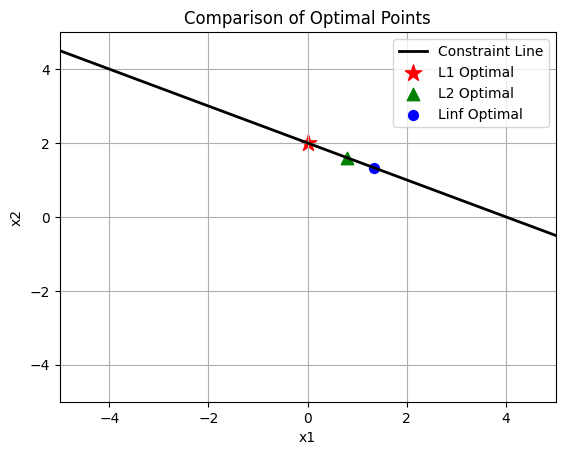

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# ----------------------------------------------------------
# Constraint:
# x1 + 2x2 = 4
# ----------------------------------------------------------

x1 = np.linspace(-5,5,400)
x2 = (4 - x1)/2

# ----------------------------------------------------------
# Meshgrid
# ----------------------------------------------------------

X1, X2 = np.meshgrid(np.linspace(-5,5,400),
                     np.linspace(-5,5,400))

# ----------------------------------------------------------
# Norms
# ----------------------------------------------------------

L1 = np.abs(X1) + np.abs(X2)

L2 = np.sqrt(X1**2 + X2**2)

Linf = np.maximum(np.abs(X1), np.abs(X2))

# ----------------------------------------------------------
# Optimization Variables
# ----------------------------------------------------------

x = cp.Variable((2,1))

A = np.array([[1,2]])
b = np.array([[4]])

# ----------------------------------------------------------
# L1 Norm Minimization
# ----------------------------------------------------------

objective1 = cp.Minimize(cp.norm(x,1))

constraints = [A @ x == b]

problem1 = cp.Problem(objective1, constraints)

problem1.solve()

xL1 = x.value
print(xL1.shape)

print("L1 Optimal Solution")
print(xL1)

# ----------------------------------------------------------
# L2 Norm Minimization
# ----------------------------------------------------------

objective2 = cp.Minimize(cp.norm(x,2))

problem2 = cp.Problem(objective2, constraints)

problem2.solve()

xL2 = x.value

print("\nL2 Optimal Solution")
print(xL2)

# ----------------------------------------------------------
# Linf Norm Minimization
# ----------------------------------------------------------

objective3 = cp.Minimize(cp.norm(x,"inf"))

problem3 = cp.Problem(objective3, constraints)

problem3.solve()

xLinf = x.value

print("\nLinf Optimal Solution")
print(xLinf)
# ==========================================================
# All Optimal Points Together
# ==========================================================

plt.plot(x1, x2,
            '-k',
            linewidth=2,
            label='Constraint Line')

# L1 Point
plt.scatter(xL1[0,0],
               xL1[1,0],
               color='red',
               s=150,
               marker='*',
               label='L1 Optimal')

# L2 Point
plt.scatter(xL2[0,0],
               xL2[1,0],
               color='green',
               s=80,
               marker='^',
               label='L2 Optimal')

# Linf Point
plt.scatter(xLinf[0,0],
               xLinf[1,0],
               color='blue',
               s=200,
               marker='.',
               label='Linf Optimal')

plt.title('Comparison of Optimal Points')

plt.xlabel('x1')
plt.ylabel('x2')

plt.xlim([-5,5])
plt.ylim([-5,5])

plt.grid()

plt.legend()


plt.show()

## 7. Geometric Interpretation

From the plots, we can observe the distinct geometric properties of each norm's minimization:

*   **$\mathcal{L}_1$ Norm:** The optimal solution (red asterisk) lies on an axis, making one of the components zero (or close to zero). This illustrates the sparsity-inducing property of the $\mathcal{L}_1$ norm.

*   **$\mathcal{L}_2$ Norm:** The optimal solution (green triangle) is the point on the constraint line closest to the origin. This is the intuitive 'shortest distance' solution.

*   **$\mathcal{L}_\infty$ Norm:** The optimal solution (blue dot) lies on a point where the absolute values of its components are equal. It is often found at the 'corners' of the L-infinity ball (square).

Each norm's 'ball' (the set of points with a norm less than or equal to a constant) has a different shape. The optimization problem effectively finds the smallest possible 'ball' (centered at the origin) that intersects the feasible region (the constraint line). The point of intersection is the optimal solution.

## Conclusion

This notebook provided a geometric exploration of $\mathcal{L}_1$, $\mathcal{L}_2$, and $\mathcal{L}_\infty$ norm minimization problems under a linear constraint. We used `cvxpy` to solve these convex optimization problems and `matplotlib` to visualize the norm contours and the optimal solutions. The visualizations clearly demonstrated how the choice of norm significantly impacts the resulting optimal solution, highlighting their unique properties and applications in various fields like machine learning (e.g., $\mathcal{L}_1$ for feature selection, $\mathcal{L}_2$ for regularization).

## Practice Questions

### Question 1: Exploring a New Linear Constraint

**Task:** Modify the relevant code sections to solve the norm minimization problems under a *new constraint*: `2x1 + x2 = 3`.

**Instructions:**
1.  **Update Constraint:** In the code blocks where `x1`, `x2` are defined for plotting the constraint line, and where `A` and `b` are defined for `cvxpy` constraints, change them to reflect `2x1 + x2 = 3`.
2.  **Re-run Optimization:** Execute the `cvxpy` optimization cells for L1, L2, and L-infinity norms with this new constraint.
3.  **Visualize:** Generate a new plot (similar to the 'Comparison of Optimal Points' plot in Section 6) that displays:
    *   The new constraint line (`2x1 + x2 = 3`).
    *   The new L1 optimal point.
    *   The new L2 optimal point.
    *   The new L-infinity optimal point.

**Discussion:** Based on your new plot, describe how the optimal solutions for L1, L2, and L-infinity have shifted compared to the original constraint (`x1 + 2x2 = 4`). Explain the geometric reasons for these changes, referring to the shapes of the norm contours and how they interact with the new constraint line.

In [ ]:
# Code Here

### Question 2: Minimizing Distance to an Arbitrary Point (L1 Norm)

**Task:** Instead of minimizing the norm of `x` (distance to the origin), consider minimizing the L1 distance from `x` to a specific point `c = [2, -1]^T` (i.e., `||x - c||_1`). Keep the *original constraint* `x1 + 2x2 = 4`.

**Instructions:**
1.  **Define New Objective:** In a new code cell, define a `cvxpy` variable `x_new = cp.Variable((2,1))`. Set the objective as `cp.Minimize(cp.norm(x_new - np.array([[2], [-1]]), 1))`.
2.  **Solve:** Use the original constraint `[A @ x_new == b]` and solve this new optimization problem with `cvxpy`.
3.  **Visualize:** Generate a plot that shows:
    *   The original constraint line (`x1 + 2x2 = 4`).
    *   The contours of the objective function `||x - c||_1` (these will be diamond shapes centered at `c = [2, -1]^T`).
    *   Mark the optimal solution `x_new.value` on the plot.
    *   Mark the point `c = [2, -1]^T` on the plot.

**Discussion:** Explain the geometric meaning of `||x - c||_1` minimization in this context. How does the optimal solution relate to the point `c` and the constraint line? How is this different from minimizing `||x||_1`?

In [ ]:
# Code Here

# **Part B: Introduction to Probability and Statistics**

##Introduction to Probability and Statistics

This notebook delves into fundamental concepts of probability and statistics, essential for understanding data. We'll explore how to generate random data following a normal distribution and then calculate key statistical measures such as mean, variance, standard deviation, median, and mode. Visualizations like histograms, probability density plots, and box plots will help us understand the distribution and characteristics of the data. Finally, we'll compare datasets with low and high variance to illustrate its impact on data spread.

## **1. Importing Necessary Libraries**

Before we begin, we need to import the necessary Python libraries that will enable us to perform numerical operations, statistical calculations, and data visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## **2. Dataset Generation**

To perform statistical analysis, we first need a dataset. In this section, we'll generate a synthetic dataset using a normal (Gaussian) distribution. The normal distribution is a very common probability distribution in nature and statistics due to the Central Limit Theorem.


### Important Python Functions:

*   **`np.random.normal(loc, scale, size)`:** This `numpy` function generates random samples from a normal (Gaussian) distribution.
    *   `loc`: The mean (μ) of the distribution. This is the center of the bell curve.
    *   `scale`: The standard deviation (σ) of the distribution. This determines how spread out the data is.
    *   `size`: The number of random samples to generate.

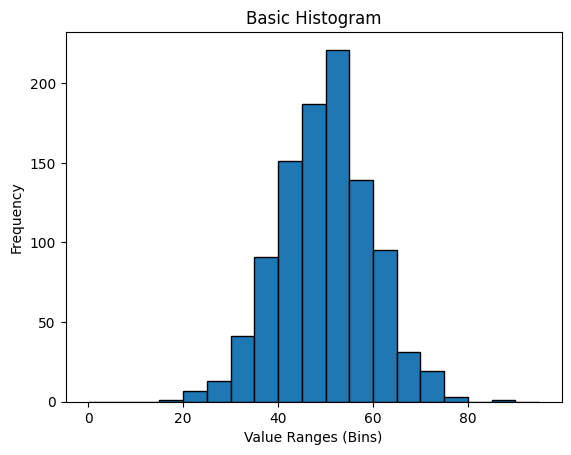

In [69]:
import numpy as np
# import matplotlib.pyplot as plt

data = np.random.normal(loc=50,
                        scale=10,
                        size=1000)

plt.hist(data, bins=range(0, 100, 5), edgecolor='black')

plt.title("Basic Histogram")
plt.xlabel("Value Ranges (Bins)")
plt.ylabel("Frequency")

plt.show()




The code generates an array named `data` containing 1000 random numbers. These numbers are drawn from a normal distribution with a mean of 50 and a standard deviation of 10. This means that, on average, the numbers will be around 50, and about 68% of the numbers will fall between 40 and 60 (i.e., within one standard deviation from the mean).

## **3. Mean, Variance, Standard Deviation, Median, and Mode**

These are fundamental statistical measures used to describe the central tendency and dispersion of a dataset. Understanding them helps us summarize and interpret the characteristics of our data.


1.  **Mean (Average):** The sum of all values divided by the number of values. It represents the central value of a set of numbers. It is sensitive to outliers.
    *   Formula: $$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

2.  **Variance:** Measures how far a set of numbers are spread out from their average value. A high variance indicates that data points are spread out over a wider range, while a low variance indicates that data points are clustered closely around the mean.
    *   Formula: $$\sigma^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n}$$

3.  **Standard Deviation:** The square root of the variance. It's a widely used measure of data dispersion, expressed in the same units as the data itself, making it easier to interpret than variance.
    *   Formula: $$\sigma = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n}}$$

4.  **Median:** The middle value in a dataset when the values are arranged in ascending or descending order. If there's an even number of data points, the median is the average of the two middle values. It is less affected by outliers than the mean.



### Important Python Functions:

*   **`np.mean(array)`:** Computes the arithmetic mean along the specified axis.
*   **`np.var(array)`:** Computes the variance along the specified axis.
*   **`np.std(array)`:** Computes the standard deviation along the specified axis.
*   **`np.median(array)`:** Computes the median along the specified axis.


In [70]:
import numpy as np
from scipy import stats

data = np.random.normal(loc=50,
                        scale=10,
                        size=1000)
meanValue = np.mean(data)
varianceValue = np.var(data)
stdValue = np.std(data)
medianValue = np.median(data)
modeValue = stats.mode(data,keepdims=True)

print("\nMean")
print(meanValue)

print("\nVariance")
print(varianceValue)



print("\nStandard Deviation")
print(stdValue)

print("\nMedian")
print(medianValue)




Mean
50.10984854910872

Variance
91.85160203082444

Standard Deviation
9.583924145715285

Median
50.22584595464389


## **4. Histogram and Probability Density Plot**

Visualizing the distribution of data is crucial for understanding its underlying patterns. Histograms and probability density plots are powerful tools for this purpose.

1.  **Histogram:** A histogram is a graphical representation of the distribution of numerical data. It divides the data into a series of bins (intervals) and counts how many data points fall into each bin. The height of each bar represents the frequency (or count) of data points within that bin.

2.  **Probability Density Plot (Normalized Histogram):** A probability density plot is essentially a histogram where the area of each bar sums to 1. This means the y-axis represents probability density rather than raw counts. It's particularly useful for visualizing the shape of a continuous distribution and comparing it to theoretical probability density functions.

### Important Python Functions:

*   **`plt.figure(figsize)`:** Creates a new figure, or activates an existing figure. `figsize` sets the width and height of the figure in inches.
*   **`plt.hist(data, bins, density)`:** Plots a histogram.
    *   `data`: The input data array.
    *   `bins`: Defines the number of equal-width bins in the range, or a sequence of bin edges. More bins can show more detail, fewer bins can smooth out noise.
    *   `density=True`: If `True`, the histogram will be normalized such that the integral over the range is 1. This means the y-axis shows probability density.
*   **`plt.title(string)`:** Sets the title of the plot.
*   **`plt.xlabel(string)`:** Sets the label for the x-axis.
*   **`plt.ylabel(string)`:** Sets the label for the y-axis.
*   **`plt.grid()`:** Adds a grid to the plot for better readability.
*   **`plt.show()`:** Displays the figure.

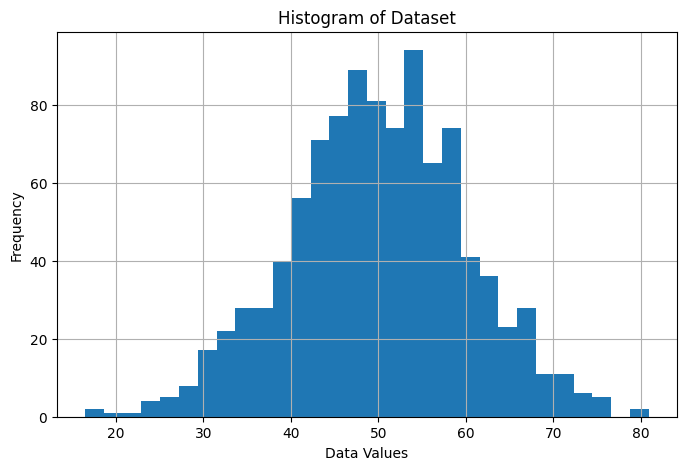

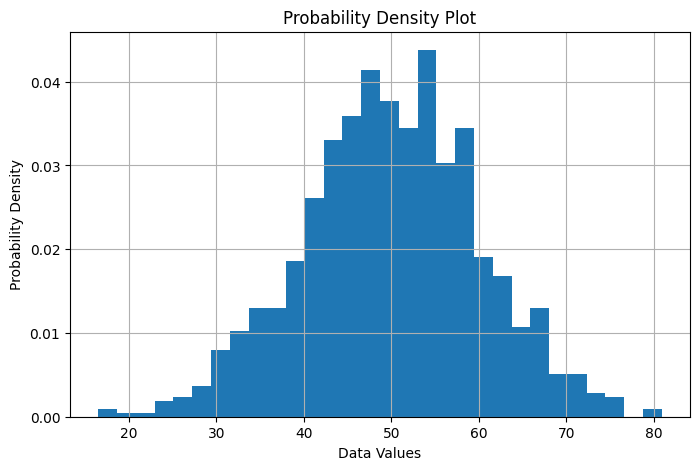

In [71]:
import numpy as np
import matplotlib.pyplot as plt
data = np.random.normal(loc=50,
                        scale=10,
                        size=1000)

plt.figure(figsize=(8,5))

plt.hist(data,
         bins=30)

plt.title('Histogram of Dataset')

plt.xlabel('Data Values')

plt.ylabel('Frequency')

plt.grid()

plt.show()

plt.figure(figsize=(8,5))

plt.hist(data,
         bins=30,
         density=True)

plt.title('Probability Density Plot')

plt.xlabel('Data Values')

plt.ylabel('Probability Density')

plt.grid()

plt.show()



1.  **Histogram of Dataset:**
    *   This plot shows the raw counts of data points falling into 30 equally spaced bins. You can clearly see a bell-shaped curve, which is characteristic of a normal distribution. The peak of the histogram is around 50, confirming the mean of our generated data.
    *   The x-axis represents the `Data Values`, and the y-axis represents the `Frequency` (how many times a value or range of values appeared).

2.  **Probability Density Plot:**
    *   This plot has a very similar shape to the histogram, but its y-axis is scaled to represent `Probability Density`. The total area under this curve would theoretically be 1. This plot provides a smoothed representation of the underlying probability distribution of our data. It again shows that values around 50 have the highest probability density.

## **5. Low Variance vs High Variance Comparison**

Variance and standard deviation are critical for understanding the spread or dispersion of a dataset. To illustrate this, we'll generate two new datasets, both with the same mean but different standard deviations.

*   **Low Variance:** When data has low variance, the data points are tightly clustered around the mean. This results in a tall, narrow bell curve in a histogram.
*   **High Variance:** When data has high variance, the data points are spread out over a wider range, further away from the mean. This results in a short, wide bell curve in a histogram.


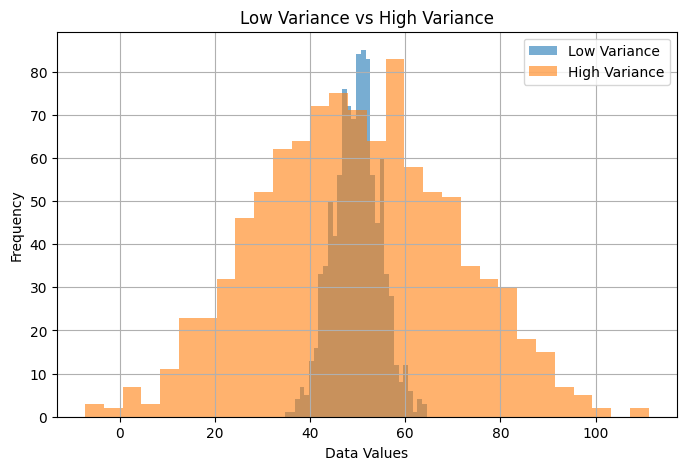

In [61]:
import numpy as np
import matplotlib.pyplot as plt

dataLowVar = np.random.normal(loc=50,
                              scale=5,
                              size=1000)

dataHighVar = np.random.normal(loc=50,
                               scale=20,
                               size=1000)

plt.figure(figsize=(8,5))

plt.hist(dataLowVar,
         bins=30,
         alpha=0.6,
         label='Low Variance')

plt.hist(dataHighVar,
         bins=30,
         alpha=0.6,
         label='High Variance')

plt.title('Low Variance vs High Variance')

plt.xlabel('Data Values')

plt.ylabel('Frequency')

plt.grid()

plt.legend()

plt.show()


*   **Blue Bars (Low Variance):** This histogram represents `dataLowVar` (mean=50, std=5). Notice how the bars are taller and narrower, indicating that most of the data points are concentrated closely around the mean of 50. The spread is relatively small.

*   **Orange Bars (High Variance):** This histogram represents `dataHighVar` (mean=50, std=20). Here, the bars are shorter and much wider, demonstrating that the data points are much more spread out across a larger range of values, even though the mean is still 50. The distribution is flatter and covers a broader spectrum on the x-axis.

This comparison clearly illustrates the direct relationship between standard deviation (or variance) and the spread of data. A smaller standard deviation leads to data points being closer to the mean, while a larger standard deviation means the data points are more dispersed.

## Conclusion

From the exercises above, we've gained several key insights into our data:

*   **Central Tendency:** The mean and median values of the initial dataset are very close to each other (around 50), which is typical for a symmetrically distributed dataset like the normal distribution. This indicates the center of our data.

*   **Data Dispersion:** The standard deviation and variance effectively quantify the spread of the data. A standard deviation of 10 means that, on average, data points deviate by about 10 units from the mean. The histogram and box plot visually confirm this spread.

*   **Distribution Shape:** Both the histogram and probability density plot show a classic bell-shaped curve, characteristic of a normal distribution. This shape is fundamental in many statistical tests and models.

*   **Impact of Variance:** The comparison between low and high variance datasets clearly demonstrates how varying the standard deviation directly impacts the spread of the data. A dataset with lower variance is more predictable and consistent, with values clustered around the mean, whereas a higher variance implies greater variability and a wider range of values.

## **Practice Questions**
### **Question 1: Exploring a Small Fixed Dataset**

Consider the following small fixed dataset: `[10, 20, 30, 40, 50, 60, 70]`.

a.  **Manual Calculation:** Without using any Python functions, manually calculate the mean, median, variance, and standard deviation for this dataset. Show your work.

b.  **Histogram Prediction:** Describe what you would expect the histogram of this dataset to look like. What would be the approximate shape and where would the bars be located?

c.  **Python Verification:** Use `numpy` and `scipy.stats` to verify your manual calculations for the mean, median, variance, and standard deviation.

d.  **Visualization:** Create a histogram and a box plot for this dataset using `matplotlib`. Comment on what these plots reveal about the data compared to your predictions and calculations.


### **Question 2: Interpreting Statistical Measures**

Consider two datasets, `data_A` generated with `np.random.normal(loc=75, scale=8, size=1000)` and `data_B` generated with `np.random.normal(loc=75, scale=25, size=1000)`.

a.  Without running any code, what would you expect the approximate mean and median to be for both `data_A` and `data_B`? Explain your reasoning.

b.  How would the standard deviation of `data_A` compare to that of `data_B`? What does this difference in standard deviation imply about the spread of values in each dataset?

### **Question 3: Understanding Visualizations and Variance**

Imagine you are presented with two box plots for different datasets, `Dataset X` and `Dataset Y`. The box plot for `Dataset X` shows a very short box (small IQR) and short whiskers, with no outliers. The box plot for `Dataset Y` shows a much taller box (large IQR) and longer whiskers, also with no outliers.

a.  Based solely on the description of the box plots, which dataset would you infer has a lower variance, and why?

b.  If you were to visualize these two datasets using histograms, how would you expect their shapes (height and width of the bell curve) to differ, assuming both are normally distributed around the same mean?


******** Data A ********
Mean: 75.31475433067634
Variance: 60.302822912779455
Standard Deviation: 7.765489225591614
Median: 75.5693635587422

******** Data B ********
Mean: 75.28789975572288
Variance: 644.9488354483343
Standard Deviation: 25.39584287729656
Median: 76.17780584723735
******** xxxxx ********


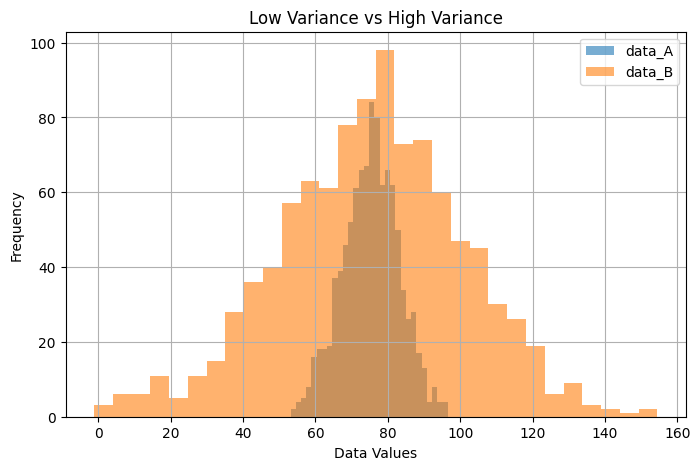

In [77]:
# Question 2
import numpy as np
import matplotlib.pyplot as plt

data_A = np.random.normal(loc=75, scale=8, size=1000)
data_B = np.random.normal(loc=75, scale=25, size=1000)

print("\n******** Data A ********")
meanValue = np.mean(data_A)
varianceValue = np.var(data_A)
stdValue = np.std(data_A)
medianValue = np.median(data_A)
modeValue = stats.mode(data_A, keepdims=True)

print("Mean:", meanValue)
print("Variance:", varianceValue)
print("Standard Deviation:", stdValue)
print("Median:", medianValue)

print("\n******** Data B ********")
meanValue = np.mean(data_B)
varianceValue = np.var(data_B)
stdValue = np.std(data_B)
medianValue = np.median(data_B)
modeValue = stats.mode(data_B, keepdims=True)

print("Mean:", meanValue)
print("Variance:", varianceValue)
print("Standard Deviation:", stdValue)
print("Median:", medianValue)

print("******** xxxxx ********")

plt.figure(figsize=(8,5))

plt.hist(data_A,
         bins=30,
         alpha=0.6,
         label='data_A')

plt.hist(data_B,
         bins=30,
         alpha=0.6,
         label='data_B')

plt.title('Low Variance vs High Variance')
plt.xlabel('Data Values')
plt.ylabel('Frequency')
plt.grid()
plt.legend()
plt.show()

